<a href="https://colab.research.google.com/github/rafaelzoric/DriverFatigueDetectionAndPreventionSystem/blob/main/SleepAway_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()   # select kaggle.json when prompted

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rafaelzoric","key":"ebd86ff1ad13259d88da31c049c79e43"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install kaggle -q
!kaggle datasets download -d akashshingha850/mrl-eye-dataset
!unzip -q mrl-eye-dataset.zip -d mrl_raw

Dataset URL: https://www.kaggle.com/datasets/akashshingha850/mrl-eye-dataset
License(s): MIT
100% 329M/329M [00:03<00:00, 91.9MB/s]



In [5]:
!find mrl_raw -maxdepth 3 -type d | head -30
!find mrl_raw -name "*.png" | head -5


mrl_raw
mrl_raw/data
mrl_raw/data/val
mrl_raw/data/val/awake
mrl_raw/data/val/sleepy
mrl_raw/data/train
mrl_raw/data/train/awake
mrl_raw/data/train/sleepy
mrl_raw/data/test
mrl_raw/data/test/awake
mrl_raw/data/test/sleepy
mrl_raw/data/val/awake/s0032_06119_0_0_1_1_1_02.png
mrl_raw/data/val/awake/s0032_05188_0_0_1_2_1_02.png
mrl_raw/data/val/awake/s0021_00244_0_0_1_0_0_01.png
mrl_raw/data/val/awake/s0035_00459_0_1_1_2_1_02.png
mrl_raw/data/val/awake/s0014_04188_0_0_1_0_0_01.png


In [6]:
!mv mrl_raw/data/train/awake  mrl_raw/data/train/open
!mv mrl_raw/data/train/sleepy mrl_raw/data/train/closed
!mv mrl_raw/data/val/awake    mrl_raw/data/val/open
!mv mrl_raw/data/val/sleepy   mrl_raw/data/val/closed
!mv mrl_raw/data/test/awake   mrl_raw/data/test/open
!mv mrl_raw/data/test/sleepy  mrl_raw/data/test/closed


In [7]:
import glob

for split in ["train", "val", "test"]:
    n_open   = len(glob.glob(f"mrl_raw/data/{split}/open/*.png"))
    n_closed = len(glob.glob(f"mrl_raw/data/{split}/closed/*.png"))
    print(f"{split:6s} -> open: {n_open:6d}  closed: {n_closed:6d}")

train  -> open:  25770  closed:  25167
val    -> open:   8591  closed:   8389
test   -> open:   8591  closed:   8390


In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE   = 64
BATCH_SIZE = 128
EPOCHS     = 25
SEED       = 42
MODEL_OUT  = "eye_state.tflite"

print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
train_ds = keras.utils.image_dataset_from_directory(
    "mrl_raw/data/train",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
)

val_ds = keras.utils.image_dataset_from_directory(
    "mrl_raw/data/val",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
)

test_ds = keras.utils.image_dataset_from_directory(
    "mrl_raw/data/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
)

print("Class names:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 50937 files belonging to 2 classes.
Found 16980 files belonging to 2 classes.
Found 16981 files belonging to 2 classes.
Class names: ['closed', 'open']


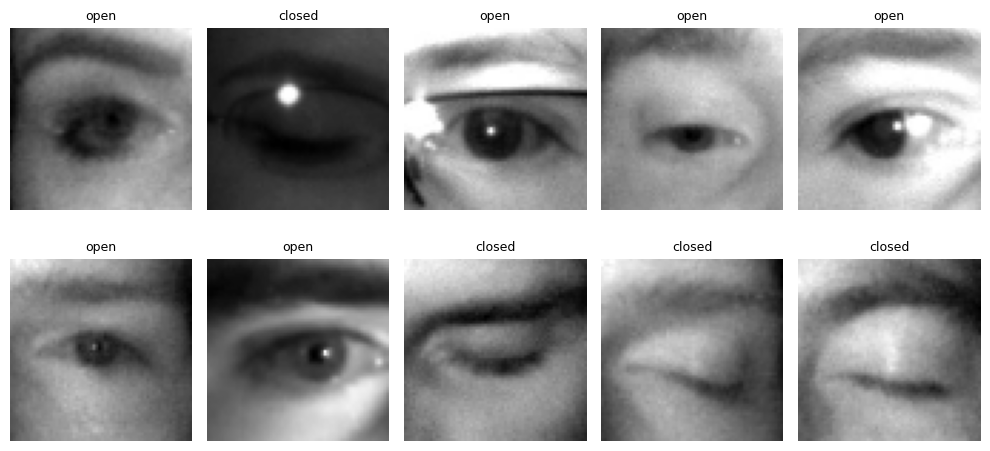

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title("open" if labels[i] == 1 else "closed", fontsize=9)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Rescaling(1.0 / 255),

    # Augmentation — simulates real dashboard variation
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.25, value_range=(0.0, 1.0)),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 64, 64, 1)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 64, 64, 1)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,633 (100.13 KB)

 Non-trainable params: 224 (896.00 B)

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=6, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6443 - loss: 0.6090 - precision: 0.6699 - recall: 0.5854 - val_accuracy: 0.5811 - val_loss: 0.7480 - val_precision: 0.9914 - val_recall: 0.1736 - learning_rate: 0.0010
Epoch 2/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8828 - loss: 0.2805 - precision: 0.8967 - recall: 0.8684 - val_accuracy: 0.7744 - val_loss: 0.4907 - val_precision: 0.9987 - val_recall: 0.5548 - learning_rate: 0.0010
Epoch 3/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9359 - loss: 0.1657 - precision: 0.9448 - recall: 0.9274 - val_accuracy: 0.9508 - val_loss: 0.1236 - val_precision: 0.9879 - val_recall: 0.9140 - learning_rate: 0.0010
Epoch 4/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9490 - loss: 0.1358 - precision: 0.9553 - recall: 0.9434 - val_accuracy: 0.8479 - val_loss: 0.3309 - val_precision: 0.7706 - val_recall: 0.9958 - learning_rate: 0.0010
Epoch 5/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - 

In [13]:
print("--- Validation ---")
model.evaluate(val_ds, return_dict=True)

print("\n--- Test (unseen subjects) ---")
results = model.evaluate(test_ds, return_dict=True)
for k, v in results.items():
    print(f"  {k}: {v:.4f}")

--- Validation ---
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9867 - loss: 0.0378 - precision: 0.9880 - recall: 0.9857

--- Test (unseen subjects) ---
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9853 - loss: 0.0406 - precision: 0.9859 - recall: 0.9850
  accuracy: 0.9853
  loss: 0.0406
  precision: 0.9859
  recall: 0.9850


In [14]:
def representative_data_gen():
    for images, _ in val_ds.take(50):
        for i in range(images.shape[0]):
            yield [tf.cast(images[i:i+1], tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

tflite_model = converter.convert()

with open(MODEL_OUT, "wb") as f:
    f.write(tflite_model)

print(f"Saved {MODEL_OUT} — {len(tflite_model)/1024:.1f} KB")

Saved artifact at '/tmp/tmpo_tx8xlt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139561214472656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214473424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214474576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214475536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214475344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214474768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214472848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214476112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561211429328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561211430480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214474192:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved eye_state.tflite — 35.7 KB


In [15]:
from google.colab import files
files.download("eye_state.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
def representative_data_gen():
    for images, _ in val_ds.take(50):
        for i in range(images.shape[0]):
            yield [tf.cast(images[i:i+1], tf.float32)]

variants = {}

# 1. FLOAT32 — no quantisation. Highest accuracy, largest file.
conv = tf.lite.TFLiteConverter.from_keras_model(model)
variants["eye_state_float32.tflite"] = conv.convert()

# 2. FLOAT16 — half precision weights. Near-identical accuracy, half size.
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
variants["eye_state_float16.tflite"] = conv.convert()

# 3. DYNAMIC RANGE — int8 weights, float activations. Good middle ground.
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
variants["eye_state_dynamic.tflite"] = conv.convert()

# 4. FULL INT8 — what you already have. Smallest and fastest.
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_data_gen
variants["eye_state_int8.tflite"] = conv.convert()

for name, blob in variants.items():
    with open(name, "wb") as f:
        f.write(blob)
    print(f"{name:32s} {len(blob)/1024:8.1f} KB")

Saved artifact at '/tmp/tmp2qdh_zzx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139561214472656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214473424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214474576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214475536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214475344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214474768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214472848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214476112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561211429328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561211430480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139561214474192:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


eye_state_float32.tflite            105.7 KB
eye_state_float16.tflite             57.4 KB
eye_state_dynamic.tflite             33.6 KB
eye_state_int8.tflite                35.7 KB


In [17]:
import numpy as np
import time

def eval_tflite(path, dataset, max_batches=40):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()

    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    in_scale, in_zero   = inp.get("quantization", (0.0, 0))
    out_scale, out_zero = out.get("quantization", (0.0, 0))

    correct = total = 0
    times = []

    for images, labels in dataset.take(max_batches):
        for i in range(images.shape[0]):
            x = images[i:i+1].numpy().astype(np.float32)

            if inp["dtype"] == np.int8:
                x = np.clip(x / in_scale + in_zero, -128, 127).astype(np.int8)
            elif inp["dtype"] == np.uint8:
                x = np.clip(x, 0, 255).astype(np.uint8)

            t0 = time.perf_counter()
            interp.set_tensor(inp["index"], x)
            interp.invoke()
            y = interp.get_tensor(out["index"])
            times.append(time.perf_counter() - t0)

            if out["dtype"] in (np.int8, np.uint8) and out_scale:
                y = (y.astype(np.float32) - out_zero) * out_scale

            pred = 1 if float(np.squeeze(y)) >= 0.5 else 0
            if pred == int(labels[i].numpy()):
                correct += 1
            total += 1

    return correct / total, np.mean(times) * 1000

print(f"{'Model':<32}{'Accuracy':>10}{'ms/frame':>12}")
print("-" * 54)
for name in variants:
    acc, ms = eval_tflite(name, test_ds)
    print(f"{name:<32}{acc:>10.4f}{ms:>12.2f}")

Model                             Accuracy    ms/frame
------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/tmp/ipykernel_1084/2771217011.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if pred == int(labels[i].numpy()):


eye_state_float32.tflite            0.9859        0.50
eye_state_float16.tflite            0.9857        0.54
eye_state_dynamic.tflite            0.9854        0.58
eye_state_int8.tflite               0.5813        0.81


In [18]:
from google.colab import files
for name in variants:
    files.download(name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>